In [1]:
# 1. ถอนการติดตั้งแพ็กเกจ OpenCV เดิมทั้งหมดที่อาจขัดแย้งกัน
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python

# 2. ติดตั้ง opencv-python ใหม่แบบ Clean Install
!pip install opencv-python

# . ติดตั้ง mediapipe
!pip install mediapipe


Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 MB 9.9 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/kaiegg/Face-Emotion-Recognition
%cd Face-Emotion-Recognition

Mounted at /content/drive
Cloning into 'Face-Emotion-Recognition'...
remote: Enumerating objects: 5791, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 5791 (delta 8), reused 2 (delta 2), pack-reused 5772 (from 1)
Receiving objects: 100% (5791/5791), 178.32 MiB | 37.30 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Updating files: 100% (5927/5927), done.
/content/Face-Emotion-Recognition


In [ ]:
!ls -la
!ls -la data/6_CategoryProcessed/
!python emotion.py
!python emotion_6cat.py

total 88
drwxr-xr-x 6 root root 4096 Sep  3 09:35 .
drwxr-xr-x 1 root root 4096 Sep  3 09:35 ..
drwxr-xr-x 4 root root 4096 Sep  3 09:35 data
-rw-r--r-- 1 root root 8196 Sep  3 09:35 .DS_Store
-rw-r--r-- 1 root root  361 Sep  3 09:35 emotion_6cat.py
-rw-r--r-- 1 root root 1256 Sep  3 09:35 emotion_7cat.py
-rw-r--r-- 1 root root 4024 Sep  3 09:35 emotion_BTFER7.py
-rw-r--r-- 1 root root 6549 Sep  3 09:35 emotion_camera.py
-rw-r--r-- 1 root root 4283 Sep  3 09:35 emotion.py
-rw-r--r-- 1 root root 4283 Sep  3 09:35 emotion_rev0.py
-rw-r--r-- 1 root root 4283 Sep  3 09:35 emotion_rev1.py
drwxr-xr-x 8 root root 4096 Sep  3 09:35 .git
drwxr-xr-x 2 root root 4096 Sep  3 09:35 haarcascades
drwxr-xr-x 2 root root 4096 Sep  3 09:35 models
-rw-r--r-- 1 root root   26 Sep  3 09:35 README.md
-rw-r--r-- 1 root root 2080 Sep  3 09:35 realtime_face_test.py
total 16
drwxr-xr-x 4 root root 4096 Sep  3 09:35 .
drwxr-xr-x 4 root root 4096 Sep  3 09:35 ..
drwxr-xr-x 8 root root 4096 Sep  3 09:35 test
drwxr

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set image dimensions
img_height = 64
img_width = 64

# 2. Updated paths pointing to your Google Drive directory
base_dataset_path = '/content/drive/MyDrive/dataset/RAF_for_Model'
train_dir = os.path.join(base_dataset_path, 'train')
test_dir = os.path.join(base_dataset_path, 'test')

# Load categories dynamically (will automatically detect all 7 categories)
categories = sorted(os.listdir(train_dir))
print(f"Detected Categories ({len(categories)}): {categories}")

# Function to load images
def load_images(base_dir):
    data, labels = [], []
    for idx, category in enumerate(categories):
        category_path = os.path.join(base_dir, category)
        if not os.path.isdir(category_path):
            continue
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((img_width, img_height))
                data.append(np.array(img))
                labels.append(idx)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(data), np.array(labels)

# Load and normalize data
X_train_raw, y_train_raw = load_images(train_dir)
X_test_raw, y_test_raw = load_images(test_dir)

X_train_raw = X_train_raw / 255.0
X_test_raw = X_test_raw / 255.0

# Apply SMOTE only on training data
data_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
smote = SMOTE(random_state=42)
data_resampled, labels_resampled = smote.fit_resample(data_flat, y_train_raw)
data_resampled = data_resampled.reshape(-1, img_height, img_width, 3)

# One-hot encode labels
labels_resampled = to_categorical(labels_resampled, num_classes=len(categories))
y_test = to_categorical(y_test_raw, num_classes=len(categories))

# Shuffle training data
indices = np.arange(data_resampled.shape[0])
np.random.shuffle(indices)
X_train = data_resampled[indices]
y_train = labels_resampled[indices]
X_test = X_test_raw

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Model architecture
model = Sequential([
    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001), input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (2, 2), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.5),
    Dense(len(categories), activation='softmax')
])

# Compile model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr, early_stopping]
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=categories))

# 3. Save model directly back to Google Drive
save_dir = '/content/drive/MyDrive/dataset/models'
os.makedirs(save_dir, exist_ok=True)
model.save(os.path.join(save_dir, 'emotion_model_raf.h5'))
print(f"Model saved successfully in '{save_dir}/emotion_model_raf.h5'")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Detected Categories (7): ['1_Surprise', '2_Fear', '3_Disgust', '4_Happiness', '5_Sadness', '6_Anger', '7_Neutral']


KeyboardInterrupt: 

In [ ]:
from google.colab import files
import numpy as np
from PIL import Image

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Open and format image
img = Image.open(image_path).convert('RGB')
img_resized = img.resize((64, 64))

# Convert to array and normalize
img_array = np.array(img_resized) / 255.0
img_input = np.expand_dims(img_array, axis=0)  # Add batch dimension (1, 64, 64, 3)

Saving fear-183.jpg to fear-183.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


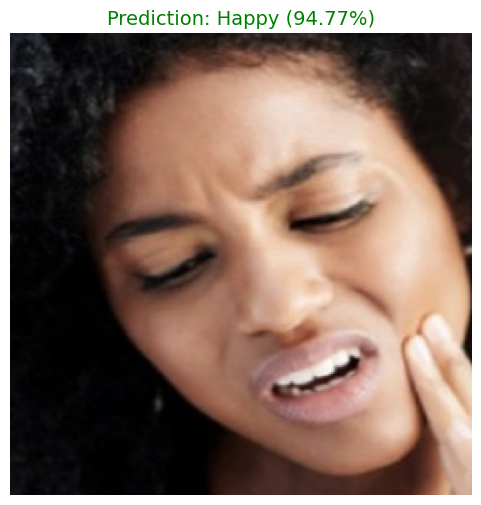


Confidence Breakdown:
 - Angry: 1.08%
 - Disgust: 0.54%
 - Fear: 2.41%
 - Happy: 94.77%
 - Neutral: 0.37%
 - Sad: 0.83%


In [ ]:
# Predict emotion probabilities
predictions = model.predict(img_input)
predicted_class_idx = np.argmax(predictions)
predicted_emotion = categories[predicted_class_idx]
confidence = predictions[0][predicted_class_idx] * 100


# Display image with predicted label
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_emotion} ({confidence:.2f}%)", fontsize=14, color='green')
plt.axis('off')
plt.show()

# Print confidence distribution
print("\nConfidence Breakdown:")
for cat, score in zip(categories, predictions[0]):
    print(f" - {cat}: {score*100:.2f}%")

In [ ]:
# Use Camera - 1

import base64
import os
import time
import urllib.request
import cv2
from IPython.display import Javascript, display
from google.colab.output import eval_js
import numpy as np
from tensorflow.keras.models import load_model

# --- PREPARATION: Download Haar Cascade XML ---
xml_filename = 'haarcascade_frontalface_default.xml'
if not os.path.exists(xml_filename):
  print(f'Downloading {xml_filename}...')
  url = f'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/{xml_filename}'
  urllib.request.urlretrieve(url, xml_filename)

# --- 1. LOAD MODEL & CATEGORIES ---
data_dir = 'data/BTFER7'
model_path = 'models/model1.h5' # Corrected typo: BTFER -> BFTER

if not os.path.exists(model_path):
  raise FileNotFoundError(f'Model not found at {model_path}')

print('Loading 8-class model...')
model = load_model(model_path)
face_detector = cv2.CascadeClassifier(xml_filename)

# Automatically read and sort category names from dataset folder
categories = sorted(
    [
        d
        for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')
    ]
)
target_size = (64, 64)


# --- 2. JAVASCRIPT WEBCAM & OVERLAY BRIDGE ---
def init_webcam_overlay():
  js = Javascript('''
        async function initWebcamOverlay() {
            if (document.getElementById('webcam_container')) return;

            const div = document.createElement('div');
            div.id = 'webcam_container';
            div.style.position = 'relative';
            div.style.width = '640px';
            div.style.height = '480px';

            const video = document.createElement('video');
            video.id = 'webcam_video';
            video.width = 640;
            video.height = 480;
            video.autoplay = true;

            const canvas = document.createElement('canvas');
            canvas.id = 'overlay_canvas';
            canvas.width = 640;
            canvas.height = 480;
            canvas.style.position = 'absolute';
            canvas.style.top = '0';
            canvas.style.left = '0';

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;

            div.appendChild(video);
            div.appendChild(canvas);
            document.body.appendChild(div);

            await new Promise((resolve) => video.onloadedmetadata = resolve);
            window.colabWebcamStream = stream;
        }
        initWebcamOverlay();
    ''')
  display(js)


def draw_overlay(detections):
  """Sends detection data (boxes + labels) to JavaScript to draw on screen."""
  js = Javascript(f'''
        function updateCanvas() {{
            const canvas = document.getElementById('overlay_canvas');
            if (!canvas) return;
            const ctx = canvas.getContext('2d');
            ctx.clearRect(0, 0, canvas.width, canvas.height);

            const detections = {detections};
            detections.forEach(det => {{
                // Draw bounding box
                ctx.strokeStyle = '#00FF00';
                ctx.lineWidth = 3;
                ctx.strokeRect(det.x, det.y, det.w, det.h);

                // Draw label background and text
                ctx.fillStyle = '#00FF00';
                ctx.font = 'bold 18px Arial';
                const text = det.label + " (" + det.conf + "%)";
                const textWidth = ctx.measureText(text).width;
                ctx.fillRect(det.x, det.y - 25 > 0 ? det.y - 25 : det.y, textWidth + 10, 25);

                ctx.fillStyle = '#000000';
                ctx.fillText(text, det.x + 5, det.y - 25 > 0 ? det.y - 7 : det.y + 18);
            }});
        }}
        updateCanvas();
    ''')
  display(js)


def stop_webcam():
  js = Javascript('''
        async function stopWebcam() {
            const div = document.getElementById('webcam_container');
            if (window.colabWebcamStream) {
                window.colabWebcamStream.getTracks().forEach(track => track.stop());
                window.colabWebcamStream = null;
            }
            if (div) div.remove();
        }
        stopWebcam();
    ''')
  display(js)


def capture_frame():
  js = Javascript('''
        async function captureFrame() {
            const video = document.getElementById('webcam_video');
            if (!video || video.videoWidth === 0) return null;

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const ctx = canvas.getContext('2d');
            ctx.drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        captureFrame();
    ''')
  display(js)
  try:
    data = eval_js('captureFrame()')
    if not data or ',' not in data:
      return None
    binary = base64.b64decode(data.split(',')[1])
    return cv2.imdecode(np.frombuffer(binary, dtype=np.uint8), cv2.IMREAD_COLOR)
  except Exception:
    return None


# --- 3. MAIN EXECUTION LOOP ---
print('\n--- Starting Real-Time Emotion Detection ---')
init_webcam_overlay()
time.sleep(3)  # Allow camera initialization

duration_seconds = 30
start_time = time.time()

try:
  while True:
    if time.time() - start_time > duration_seconds:
      print(f'\nTime limit of {duration_seconds}s reached.')
      break

    frame = capture_frame()
    if frame is None:
      continue

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(
        gray_frame, scaleFactor=1.3, minNeighbors=5
    )

    detections = []
    for x, y, w, h in faces:
      # Extract face region
      roi_bgr = frame[y : y + h, x : x + w]
      roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

      # Preprocess image
      resized_face = cv2.resize(roi_rgb, target_size) / 255.0
      face_array = np.expand_dims(resized_face, axis=0)

      # Inference
      prediction = model.predict(face_array, verbose=0)
      predicted_class = np.argmax(prediction)
      confidence = float(prediction[0][predicted_class] * 100)

      # Build JSON payload for JS overlay renderer
      detections.append({
          'x': int(x),
          'y': int(y),
          'w': int(w),
          'h': int(h),
          'label': str(categories[predicted_class]),
          'conf': f'{confidence:.1f}',
      })

    # Render bounding boxes and text directly onto webcam canvas layer
    draw_overlay(detections)

except KeyboardInterrupt:
  print('\nInterrupted by user.')
finally:
  stop_webcam()
  print('Camera closed successfully.')

Loading 8-class model...

--- Starting Real-Time Emotion Detection ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Interrupted by user.


<IPython.core.display.Javascript object>

Camera closed successfully.


In [ ]:
# Use Camera - 2

import os
import urllib.request
import cv2
import numpy as np
import base64
import time
from tensorflow.keras.models import load_model
from google.colab.output import eval_js
from IPython.display import display, Javascript

# --- PREPARATION: Download Haar Cascade XML ---
xml_filename = 'haarcascade_frontalface_default.xml'
if not os.path.exists(xml_filename):
    print(f"Downloading {xml_filename} from OpenCV GitHub...")
    url = f'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/{xml_filename}'
    try:
        urllib.request.urlretrieve(url, xml_filename)
        print("Download complete.")
    except Exception as e:
        print(f"Error downloading XML: {e}")
        raise

# --- 1. LOAD MODEL & CLASSIFIER ---
model_path = 'models/model2.h5'
if not os.path.exists(model_path):
    print(f"Error: Model file not found at {model_path}. Please ensure you trained and saved the model correctly.")
    raise SystemExit

print("Loading model...")
model = load_model(model_path)
face_detector = cv2.CascadeClassifier(xml_filename)

if face_detector.empty():
    print("Error: Failed to load Haar Cascade Classifier.")
    raise SystemExit

# Emotion categories (must match training order)
categories = ['angry', 'disgusted', 'neutral', 'sad', 'smiling', 'surprise']
target_size = (64, 64)

# --- 2. JAVASCRIPT FUNCTIONS (Colab Webcam Bridge) ---

# Function to initialize the webcam in the browser
def init_webcam():
    js = Javascript('''
        async function initWebcam() {
            // Check if element already exists to avoid duplication
            if (document.getElementById('webcam_container')) {
                return;
            }

            const div = document.createElement('div');
            div.id = 'webcam_container';
            const video = document.createElement('video');
            video.id = 'webcam_video';
            video.style.display = 'block';
            video.width = 640;
            video.height = 480;
            video.autoplay = true;

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            document.body.appendChild(div);
            div.appendChild(video);

            // Wait for video metadata to load
            await new Promise((resolve) => video.onloadedmetadata = resolve);
            // Store stream globally so we can stop it later
            window.colabWebcamStream = stream;
            console.log("Webcam initialized.");
        }
        initWebcam();
    ''')
    display(js)

# Function to stop the webcam stream and remove the video element
def stop_webcam():
    js = Javascript('''
        async function stopWebcam() {
            const div = document.getElementById('webcam_container');
            const video = document.getElementById('webcam_video');

            // Stop the stream tracks
            if (window.colabWebcamStream) {
                window.colabWebcamStream.getTracks().forEach(track => track.stop());
                window.colabWebcamStream = null;
                console.log("Webcam stream stopped.");
            }

            // Remove UI elements
            if (video) video.remove();
            if (div) div.remove();
            console.log("Webcam elements removed.");
        }
        stopWebcam();
    ''')
    display(js)

# Function to capture a single frame and send it to Python
def capture_frame():
    js = Javascript('''
        async function captureFrame() {
            const video = document.getElementById('webcam_video');
            // If the element was removed, return null
            if (!video || video.videoWidth === 0 || video.videoHeight === 0) {
                return null;
            }

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const ctx = canvas.getContext('2d');
            ctx.drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.8);
        }
        captureFrame();
    ''')
    display(js)
    try:
        data = eval_js('captureFrame()')
    except Exception:
        # Happens if JS element is gone before call completes
        return None

    if not data or ',' not in data:
        return None

    try:
        binary = base64.b64decode(data.split(',')[1])
        if len(binary) == 0:
            return None
        image_np = np.frombuffer(binary, dtype=np.uint8)
        return cv2.imdecode(image_np, cv2.IMREAD_COLOR)
    except Exception:
        return None

# --- 3. MAIN EXECUTION LOOP ---
print("\n--- Starting Emotion Recognition Program ---")
init_webcam()
print("Waiting for webcam to stabilize (Please click 'Allow' if prompted)...")
time.sleep(3) # Wait longer for user interaction

# REVISED: Updated duration to 30 seconds
duration_seconds = 30
print(f"Beginning processing loop. Will run for {duration_seconds} seconds...")

start_time = time.time()
try:
    while True:
        current_elapsed = time.time() - start_time
        if current_elapsed > duration_seconds:
            print(f"\nTime limit of {duration_seconds} seconds reached.")
            break

        frame = capture_frame()
        # If capture_frame returns None (e.g., if camera was closed), skip/break
        if frame is None:
            if current_elapsed > 5: # Give it some starting time
                print("\nUnable to capture frame. Assuming camera closed.")
                break
            continue

        if frame.size == 0:
            time.sleep(0.1)
            continue

        # Process frame
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_detector.detectMultiScale(gray_frame, scaleFactor=1.3, minNeighbors=5)

        for (x, y, w, h) in faces:
            # Extract and preprocess face
            roi_bgr = frame[y:y + h, x:x + w]
            roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

            resized_face = cv2.resize(roi_rgb, target_size)
            normalized_face = resized_face / 255.0
            face_array = np.expand_dims(normalized_face, axis=0)

            # Predict emotion
            prediction = model.predict(face_array, verbose=0)
            predicted_class = np.argmax(prediction)
            confidence = prediction[0][predicted_class] * 100

            # REVISED: Print each result on a new line (end="" removed)
            print(f"[Prediction] Elapsed: {int(current_elapsed)}s | Emotion: {categories[predicted_class]} ({confidence:.1f}%)")

except KeyboardInterrupt:
    print("\nProgram interrupted by user.")
except SystemExit:
    print("\nProgram stopped early.")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")
finally:
    # REVISED: Crucial step to ensure camera turns off automatically
    print("Stopping webcam and ending program...")
    stop_webcam()
    print("Program ended successfully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.4043 - loss: 1.7572 - val_accuracy: 0.4899 - val_loss: 1.4808 - learning_rate: 1.0000e-04
Epoch 2/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4648 - loss: 1.5523 - val_accuracy: 0.5388 - val_loss: 1.4279 - learning_rate: 1.0000e-04
Epoch 3/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.4866 - loss: 1.4705 - val_accuracy: 0.5443 - val_loss: 1.3295 - learning_rate: 1.0000e-04
Epoch 4/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5132 - loss: 1.4111 - val_accuracy: 0.5782 - val_loss: 1.2560 - learning_rate: 1.0000e-04
Epoch 5/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.5194 - loss: 1.3766 - val_accuracy: 0.5929 - val_loss: 1.2154 - learning_rate: 1.0000e-04
Epoch 6/30
767/767 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.5325 - loss: 

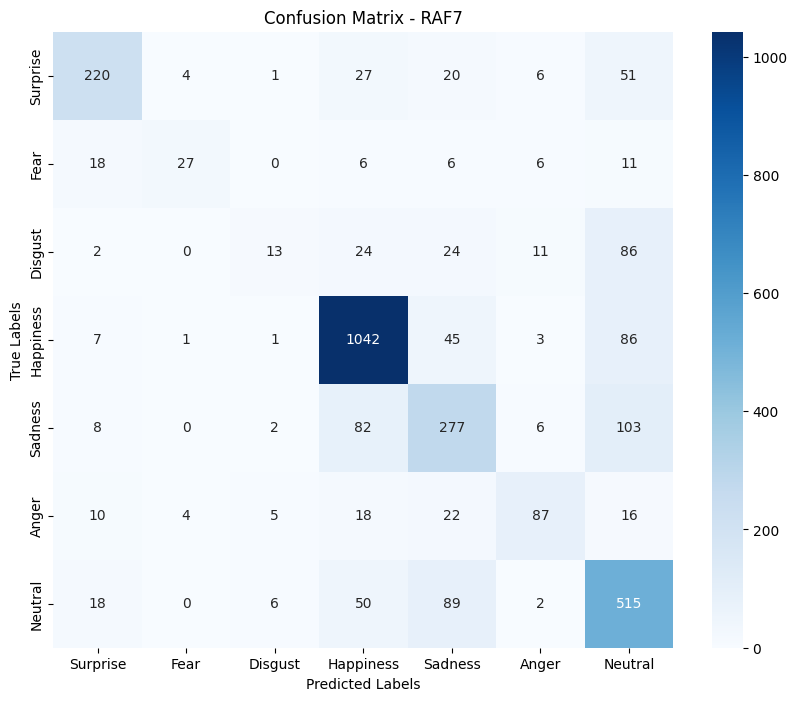

Classification Report:
              precision    recall  f1-score   support

    Surprise       0.78      0.67      0.72       329
        Fear       0.75      0.36      0.49        74
     Disgust       0.46      0.08      0.14       160
   Happiness       0.83      0.88      0.86      1185
     Sadness       0.57      0.58      0.58       478
       Anger       0.72      0.54      0.61       162
     Neutral       0.59      0.76      0.67       680

    accuracy                           0.71      3068
   macro avg       0.67      0.55      0.58      3068
weighted avg       0.71      0.71      0.70      3068

Model saved to '/content/drive/MyDrive/model/model_RAF7.h5'


In [ ]:
# train .h5 model by RAF7 dataset on Google Drive

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Dimensions & Paths
img_height = 100
img_width = 100

train_dir = '/content/drive/MyDrive/dataset/RAF_for_Model/train'
test_dir = '/content/drive/MyDrive/dataset/RAF_for_Model/test'

# 3. Parse categories
categories = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
display_categories = [cat.split('_', 1)[-1] for cat in categories]
num_classes = len(categories)

# 4. Image loading function
def load_images(base_dir):
    data, labels = [], []
    for idx, category in enumerate(categories):
        category_path = os.path.join(base_dir, category)
        if not os.path.isdir(category_path):
            continue
        for img_name in os.listdir(category_path):
            img_path = os.path.join(category_path, img_name)
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize((img_width, img_height))
                data.append(np.array(img))
                labels.append(idx)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
    return np.array(data), np.array(labels)

# 5. Load and normalize data
X_train_raw, y_train_raw = load_images(train_dir)
X_test_raw, y_test_raw = load_images(test_dir)

X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

y_train = to_categorical(y_train_raw, num_classes=num_classes)
y_test = to_categorical(y_test_raw, num_classes=num_classes)

# 6. Data Augmentation
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

# 7. Model Architecture
model = Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    data_augmentation,

    Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (2, 2), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# 8. Compile & Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 9. Train
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr, early_stopping]
)

# 10. Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Plot Confusion Matrix with cleaned category names
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=display_categories, yticklabels=display_categories)
plt.title("Confusion Matrix - RAF7")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=display_categories))

# Save
save_dir = '/content/drive/MyDrive/model'
os.makedirs(save_dir, exist_ok=True)
model.save(os.path.join(save_dir, 'model_RAF7.h5'))
print("Model saved to '/content/drive/MyDrive/model/model_RAF7.h5'")

In [ ]:
# 7 Emotion Categories

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from PIL import Image
from google.colab import drive

# 1. Mount Google Drive if running in Colab
drive.mount('/content/drive')

# 2. Path definitions
train_dir = '/content/drive/MyDrive/dataset/RAF_for_Model/test'
model_path = '/content/drive/MyDrive/model/model_RAF7.h5'

# Target image size matching the new dataset
img_height = 100
img_width = 100

# 3. Load the newly trained RAF7 model
model = load_model(model_path)

# 4. Extract categories dynamically in sorted order (matches training order)
# Categories: ['1_Surprise', '2_Fear', '3_Disgust', '4_Happiness', '5_Sadness', '6_Anger', '7_Neutral']
categories = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Optional: Clean class names for cleaner visual display (e.g., 'Surprise', 'Fear', etc.)
display_categories = [cat.split('_', 1)[-1] for cat in categories]

# 5. Helper function for single-image prediction
def predict_emotion(image_path):
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((img_width, img_height))
    img_array = np.array(img_resized) / 255.0
    img_tensor = np.expand_dims(img_array, axis=0)  # Shape: (1, 100, 100, 3)

    # Inference
    predictions = model.predict(img_tensor)[0]
    predicted_idx = np.argmax(predictions)
    confidence = predictions[predicted_idx] * 100

    predicted_label = display_categories[predicted_idx]

    # Plot results
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return predicted_label, confidence

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading images from /content/drive/MyDrive/dataset/Common_Test...


Loading 1_Surprise:   0%|          | 0/300 [00:00<?, ?it/s]

Loading 2_Fear:   0%|          | 0/300 [00:00<?, ?it/s]

Loading 3_Disgust:   0%|          | 0/300 [00:00<?, ?it/s]

Loading 4_Happiness:   0%|          | 0/300 [00:00<?, ?it/s]

Loading 5_Sadness:   0%|          | 0/300 [00:00<?, ?it/s]

Loading 6_Anger:   0%|          | 0/300 [00:00<?, ?it/s]

Loading 7_Neutral:   0%|          | 0/300 [00:00<?, ?it/s]

Running evaluation on 2100 images...
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Overall Common_Test Accuracy: 36.71%

           precision  recall  f1-score
Surprise      0.3789  0.6000    0.4645
Fear          0.6250  0.0333    0.0633
Disgust       0.5263  0.0667    0.1183
Happiness     0.3587  0.7233    0.4796
Sadness       0.4030  0.1800    0.2488
Anger         0.4307  0.3933    0.4111
Neutral       0.3082  0.5733    0.4009


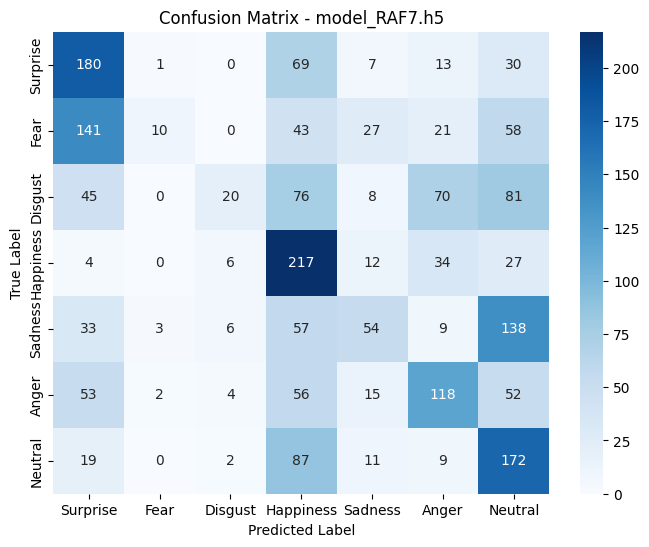

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from PIL import Image
from google.colab import drive

# ==========================================
# 1. Mount Drive & Setup Paths
# ==========================================
drive.mount('/content/drive')
#test_dir = '/content/drive/MyDrive/dataset/RAF_for_Model/test'
test_dir = '/content/drive/MyDrive/dataset/Common_Test'
model_path = '/content/drive/MyDrive/model/model_RAF7.h5'

img_height = 100
img_width = 100

# ==========================================
# 2. Load Model & Extract Class Labels
# ==========================================
model = load_model(model_path)

# Automatically fetch category folder names in sorted order
raw_categories = sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))])
class_names = [cat.split('_', 1)[-1] for cat in raw_categories]  # e.g., '1_Surprise' -> 'Surprise'

# ==========================================
# 3. Load & Preprocess Common_Test Data
# ==========================================
all_images = []
all_labels = []

print(f"Loading images from {test_dir}...")
for class_idx, category in enumerate(raw_categories):
    category_path = os.path.join(test_dir, category)
    image_files = os.listdir(category_path)

    for img_name in tqdm(image_files, desc=f"Loading {category}", leave=False):
        img_path = os.path.join(category_path, img_name)
        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((img_width, img_height))
            all_images.append(np.array(img))
            all_labels.append(class_idx)
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

X_test = np.array(all_images) / 255.0  # Normalize to [0.0, 1.0]
y_true = np.array(all_labels)

# ==========================================
# 4. Predict & Evaluate
# ==========================================
print(f"Running evaluation on {len(X_test)} images...")
y_pred_probs = model.predict(X_test, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)

# ==========================================
# 5. Display Metrics & Confusion Matrix
# ==========================================
overall_acc = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

report_df = pd.DataFrame(report).transpose().round(4)
print(f"\nOverall Common_Test Accuracy: {overall_acc * 100:.2f}%\n")
print(report_df.iloc[:-3, :3])  # Display Precision, Recall, and F1-score per category

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - model_RAF7.h5')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 12271 files belonging to 7 classes.
Found 3068 files belonging to 7 classes.
Epoch 1/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 2842s 4s/step - accuracy: 0.3914 - loss: 1.7407 - val_accuracy: 0.4876 - val_loss: 1.5536 - learning_rate: 1.0000e-04
Epoch 2/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.4629 - loss: 1.5439 - val_accuracy: 0.5362 - val_loss: 1.3591 - learning_rate: 1.0000e-04
Epoch 3/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 133s 173ms/step - accuracy: 0.4946 - loss: 1.4609 - val_accuracy: 0.5662 - val_loss: 1.2658 - learning_rate: 1.0000e-04
Epoch 4/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.5084 - loss: 1.4007 - val_accuracy: 0.5968 - val_loss: 1.2265 - learning_rate: 1.0000e-04
Epoch 5/50
767/767 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.5328 - loss: 1.3421 - val_accuracy: 0.6053 - val_loss: 1.1851 - learning_rate: 1.0000e

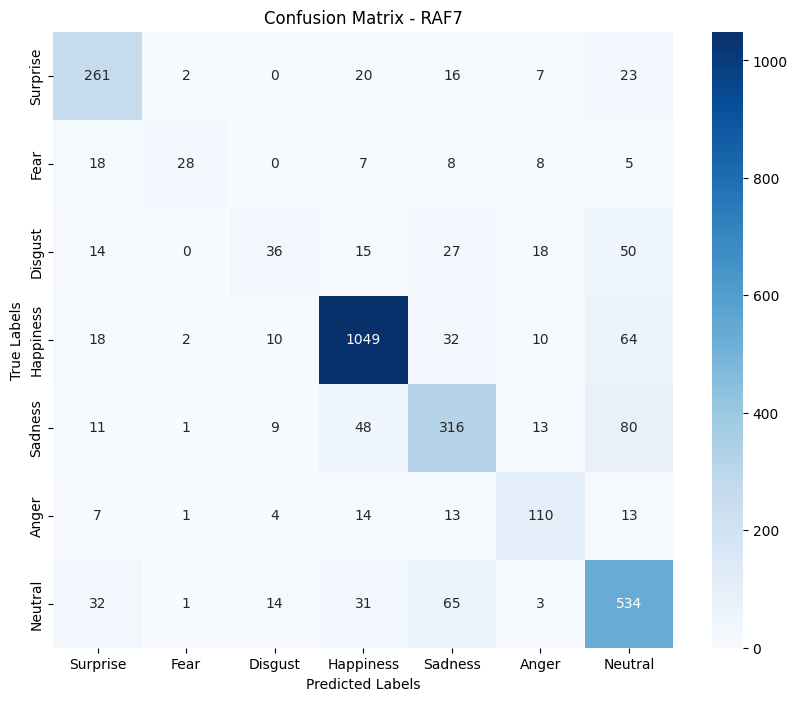


Classification Report:
              precision    recall  f1-score   support

    Surprise       0.72      0.79      0.76       329
        Fear       0.80      0.38      0.51        74
     Disgust       0.49      0.23      0.31       160
   Happiness       0.89      0.89      0.89      1185
     Sadness       0.66      0.66      0.66       478
       Anger       0.65      0.68      0.66       162
     Neutral       0.69      0.79      0.74       680

    accuracy                           0.76      3068
   macro avg       0.70      0.63      0.65      3068
weighted avg       0.76      0.76      0.75      3068

Saved artifact at '/content/saved_model_temp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  139061380181712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13906138018209

In [ ]:
# Train model on RAF7 dataset and export as an uncompressed .tar archive

import os
import tarfile
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Dimensions & Paths
img_height = 100
img_width = 100
batch_size = 16

train_dir = '/content/drive/MyDrive/dataset/RAF_for_Model/train'
test_dir = '/content/drive/MyDrive/dataset/RAF_for_Model/test'

# 3. Fast Data Streaming from Drive
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='categorical',
    shuffle=False,
)

# Extract category names
categories = train_ds.class_names
display_categories = [cat.split('_', 1)[-1] for cat in categories]
num_classes = len(categories)

# Optimize pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# 4. Model Architecture (with Integrated Normalization & Data Augmentation)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    tf.keras.layers.Rescaling(1.0 / 255.0),  # Rescale inputs directly inside graph
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.Conv2D(
        64, (3, 3), activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(
        128, (3, 3), activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(
        128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0005)
    ),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

# 5. Compile & Callbacks
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True, verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# 6. Train Model
history = model.fit(
    train_ds,
    #epochs=30,
    #epochs=3,
    epochs=50,
    validation_data=test_ds,
    callbacks=[reduce_lr, early_stopping],
)

# 7. Evaluate Model
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

# Extract true labels and model predictions
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=display_categories,
    yticklabels=display_categories,
)
plt.title("Confusion Matrix - RAF7")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

print("\nClassification Report:")
print(
    classification_report(
        y_true_classes, y_pred_classes, target_names=display_categories
    )
)

# 8. Save Model and Package into .tar Archive (Keras 3 Compatible)
save_dir = '/content/drive/MyDrive/model'
os.makedirs(save_dir, exist_ok=True)

temp_model_dir = '/content/saved_model_temp'
tar_output_path = os.path.join(save_dir, 'model_RAF7.tar')

# Export standard SavedModel directory format
model.export(temp_model_dir)

# Pack folder into uncompressed .tar archive ("w" mode)
with tarfile.open(tar_output_path, "w") as tar:
    tar.add(temp_model_dir, arcname="model_RAF7")

print(f"\nModel successfully saved and packaged to '{tar_output_path}'")